In [1]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
# import sys
# sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# from common import *

/home/wuke/anaconda3/envs/AIGEM/lib/python3.7/site-packages/Bio/pairwise2.py:283: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  BiopythonDeprecationWarning,


# input and output

In [2]:
gut_people_file = '../../Data/cell_HGM_sample/taxonomic_table.csv/raw_taxa_110.csv'
sample_info_file = '../../Data/cell_HGM_sample/sample_metadata.tsv'
sample_label_file = '../../Data/cell_HGM_sample/sample_tags.tsv'

In [3]:
gut_people = pd.read_csv(gut_people_file)
# gut_people = gut_people.head(10000)
gut_people.head(1)

,Unnamed: 0,sample,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus,...,Bacteria.Planctomycetota.Phycisphaerae.Phycisphaerales.Phycisphaeraceae.JL-ETNP-F27,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Microcystaceae.Crocosphaera,Bacteria.Pseudomonadota.Alphaproteobacteria.Rickettsiales.Rickettsiaceae.Candidatus Gigarickettsia,Bacteria.Bacillota.Bacilli.Bacillales.Bacillaceae.Streptohalobacillus,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Cyanobacteriaceae.Cyanobacterium PCC-10605,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Flavirhabdus,Bacteria.Pseudomonadota.Alphaproteobacteria.Rhodobacterales.Paracoccaceae.Octadecabacter,Bacteria.Pseudomonadota.Alphaproteobacteria.Acetobacterales.Acetobacteraceae.Swingsia,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Aurantiacicella,Archaea.Halobacteriota.Halobacteria.Halobacterales.Halobacteriaceae.Halocalculus
0,1,PRJDB10485_DRR243823,179,435,481,653,471,6,109,495,...,0,0,0,0,0,0,0,0,0,0


In [4]:
sample_info = pd.read_csv(sample_info_file,sep='\t')
sample_info.head(2)

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region
0,DRS193785,PRJDB11894,DRR304700,AMPLICON,METAGENOMIC,2021-07-02 13:48:45,24082035.0,Illumina MiSeq,japan,JP,Eastern and South-Eastern Asia
1,DRS193784,PRJDB11894,DRR304699,AMPLICON,METAGENOMIC,2021-07-02 13:48:45,13990122.0,Illumina MiSeq,japan,JP,Eastern and South-Eastern Asia


In [5]:
sample_info.shape

(168464, 11)

In [6]:
sample_info[sample_info['iso']=='CN']['geo_loc_name']

8161         china: yantai
8162         china: yantai
8163         china: yantai
8164         china: yantai
8165         china: yantai
                ...       
167287    china: chongqing
167288    china: chongqing
167289    china: chongqing
167290    china: chongqing
167291    china: chongqing
Name: geo_loc_name, Length: 10235, dtype: object

In [7]:
sample_info_dict = {}
for index,row in tqdm(sample_info.iterrows(),total=len(sample_info)):
    sampleID = row['project'] +'_' + row['srr']
    sample_info_dict[sampleID] = row['geo_loc_name']

100%|██████████| 168464/168464 [00:08<00:00, 20985.50it/s]


In [8]:
# 定义允许的国家标签
valid_countries = {
    'japan', 'usa', 'australia', 'austria', 'belgium', 'brazil', 'canada', 'colombia',
    'zimbabwe', 'denmark', 'ecuador', 'finland', 'france', 'germany', 'ghana', 'greece',
    'india', 'italy', 'israel', 'new zealand', 'south korea', 'russia', 'spain', 'uganda',
    'netherlands', 'nigeria', 'romania', 'poland', 'sweden', 'united kingdom', 'thailand', 'china'
}

# 统一标签
sample_info_dict = {
    k: (
        'japan' if str(v).lower().startswith('japan') else
        'usa' if str(v).lower().startswith('usa') else
        'australia' if str(v).lower().startswith('australia') else
        'austria' if str(v).lower().startswith('austria') else
        'belgium' if str(v).lower().startswith('belgium') else
        'brazil' if str(v).lower().startswith('brazil') else
        'canada' if str(v).lower().startswith('canada') else
        'colombia' if str(v).lower().startswith('colombia') else
        'zimbabwe' if str(v).lower().startswith('zimbabwe') else
        'denmark' if str(v).lower().startswith('denmark') else
        'ecuador' if str(v).lower().startswith('ecuador') else
        'finland' if str(v).lower().startswith('finland') else
        'france' if str(v).lower().startswith('france') else
        'germany' if str(v).lower().startswith('germany') else
        'ghana' if str(v).lower().startswith('ghana') else
        'greece' if str(v).lower().startswith('greece') else
        'india' if str(v).lower().startswith('india') else
        'italy' if str(v).lower().startswith('italy') else
        'israel' if str(v).lower().startswith('israel') else
        'new zealand' if str(v).lower().startswith('new zealand') else
        'south korea' if str(v).lower().startswith('south korea') else
        'russia' if str(v).lower().startswith('russia') else
        'spain' if str(v).lower().startswith('spain') else
        'uganda' if str(v).lower().startswith('uganda') else
        'netherlands' if str(v).lower().startswith('netherlands') else
        'nigeria' if str(v).lower().startswith('nigeria') else
        'romania' if str(v).lower().startswith('romania') else
        'poland' if str(v).lower().startswith('poland') else
        'sweden' if str(v).lower().startswith('sweden') else
        'united kingdom' if str(v).lower().startswith('united kingdom') else
        'thailand' if str(v).lower().startswith('thailand') else
        'china' if str(v).lower().startswith('china') else None
    )
    for k, v in sample_info_dict.items()
}

# 删除那些未匹配（即值为 None）的项
sample_info_dict = {k: v for k, v in sample_info_dict.items() if v in valid_countries}

In [9]:
continent_map = {
    'japan': 'Asia',
    # 'china': 'Asia',
    'india': 'Oceania',
    'south korea': 'Asia',
    'thailand': 'Oceania',
    'israel': 'Oceania',

    'australia': 'Oceania',
    'new zealand': 'Oceania',

    'usa': 'North America',
    'canada': 'North America',

    'brazil': 'South America',
    'colombia': 'South America',
    'ecuador': 'South America',

    'ghana': 'Africa',
    'uganda': 'Africa',
    'nigeria': 'Africa',
    'zimbabwe': 'Africa',

    'austria': 'Europe',
    'belgium': 'Europe',
    'denmark': 'Europe',
    'finland': 'Europe',
    'france': 'Europe',
    'germany': 'Europe',
    'greece': 'Europe',
    'italy': 'Europe',
    'netherlands': 'Europe',
    'poland': 'Europe',
    'romania': 'Europe',
    'russia': 'Europe',
    'spain': 'Europe',
    'sweden': 'Europe',
    'united kingdom': 'Europe'
}

sample_info_dict = {
    k: next((continent_map[country]
             for country in continent_map
             if str(v).lower().startswith(country)), None)
    for k, v in sample_info_dict.items()
}

# 删除无法映射的大洲（None）
sample_info_dict = {k: v for k, v in sample_info_dict.items() if v is not None}

In [10]:
sample_label = pd.read_csv(sample_label_file,sep='\t')
sample_label.head(2)

,project,srr,srs,tag,value
0,PRJDB10485,DRR243823,DRS176859,ART_drugs_current,control
1,PRJDB10485,DRR243823,DRS176859,ART_status_at_baseline,control


## 1. 获取每一个sample所在行总丰度

In [11]:
sampleID_list = gut_people['sample'].to_list()
sampleID_all_abandance_dict = dict(zip(
    gut_people['sample'],
    gut_people.iloc[:, 2:].sum(axis=1)
))

# 2.计算

In [12]:
strain_class_list = gut_people.columns.to_list()[2:]
strain_class_list = [x for x in strain_class_list if len(x.split('.'))==6 and x.split('.')[5]!='NA']
strain_family_dict = {}
for strain in strain_class_list:
    family = strain.split('.')[4]
    strain_family_dict[strain] = family
strain_genus_dict = {}
for strain in strain_class_list:
    genus = strain.split('.')[5]
    strain_genus_dict[strain] = genus

family_list = list(set(strain_family_dict.values()))
genus_list = list(set(strain_genus_dict.values()))

In [13]:
### 临时关闭
import numpy as np
from tqdm import tqdm

sample_family_abundance = {sid: {fam: 0 for fam in family_list} for sid in sampleID_list}

for strain in tqdm(gut_people.columns[2:], desc="Processing strains"):
    family = strain_family_dict.get(strain)
    if family is None:
        continue
    values = gut_people[strain].to_numpy()
    for sid, val in zip(sampleID_list, values):
        sample_family_abundance[sid][family] += val

Processing strains: 100%|██████████| 4680/4680 [08:41<00:00,  8.98it/s]


In [14]:
ref_family_list = {
    'Enterococcaceae': [],
    'Streptococcaceae': [],
    'Turicibacteraceae': [],
    'Enterobacteriaceae': [],
    'Alcaligenaceae': [],
    'Veillonellaceae': [],
    'Peptostreptococcaceae': [],
    'Porphyromonadaceae': [],
    'Erysipelotrichaceae': [],
    'Clostridiaceae': [],
    'Bifidobacteriaceae': [],
    'Rikenellaceae': [],
    'Bacteroidaceae': [],
    'Ruminococcaceae': [],
    'Lachnospiraceae': [],
}

sample_family_abundance_filter = {}

for sampleID, fam_dict in sample_family_abundance.items():
    sample_family_abundance_filter[sampleID] = {
        family: fam_dict.get(family, 0) for family in ref_family_list
    }

In [15]:
sample_family_abundance_rel = {}

for sampleID, fam_dict in sample_family_abundance_filter.items():
    total = sampleID_all_abandance_dict.get(sampleID, 0)
    if total == 0:
        print(sampleID)
        # 如果总丰度为0，防止除以0错误，全设为0
        sample_family_abundance_rel[sampleID] = {fam: 0 for fam in fam_dict}
    else:
        sample_family_abundance_rel[sampleID] = {
            fam: val / total for fam, val in fam_dict.items()
        }

# 根据标签获取相对丰度

In [16]:
# # 读取
# with open('../../Results/strain_eccounts_filter_sum.pkl', 'rb') as f:
#     strain_eccounts_filter_sum = pickle.load(f)
    
import json

# 读取 Top3
with open('./strain_eccounts_family_top3.json', 'r', encoding='utf-8') as f:
    ec_strain_enzymecounts_top3_filter = json.load(f)

# 读取 Top4
with open('./strain_eccounts_family.json', 'r', encoding='utf-8') as f:
    ec_strain_enzymecounts_top4_filter = json.load(f)


In [17]:
def calculate_score(sampleID, EC, sample_family_abundance_rel, strain_eccounts_filter_sum, ref_family_list):
    abundance = sample_family_abundance_rel[sampleID]  # 样本对应的丰度字典
    enzyme_counts = strain_eccounts_filter_sum[EC]     # EC 对应的家族计数字典
    score = 0
    for family in ref_family_list:
        a = abundance.get(family, 0)                   # 防止缺失
        e = enzyme_counts.get(family, 0)              # 防止缺失
        score += (a ** 1) * (e ** 3)
    return score

In [18]:
# 分组
region_samples_dict = {}
for sample, region in sample_info_dict.items():
    if region not in region_samples_dict:
        region_samples_dict[region] = []
    region_samples_dict[region].append(sample)

region_samples_dict

{'Asia': ['PRJDB11894_DRR304700',
  'PRJDB11894_DRR304699',
  'PRJDB11894_DRR304698',
  'PRJDB11894_DRR304697',
  'PRJDB11894_DRR304696',
  'PRJDB11894_DRR304695',
  'PRJDB11894_DRR304694',
  'PRJDB11894_DRR304693',
  'PRJDB11894_DRR304692',
  'PRJDB11894_DRR304691',
  'PRJDB11894_DRR304690',
  'PRJDB11894_DRR304689',
  'PRJDB11894_DRR304688',
  'PRJDB11894_DRR304687',
  'PRJDB11894_DRR304686',
  'PRJDB11894_DRR304685',
  'PRJDB11894_DRR304684',
  'PRJDB11894_DRR304683',
  'PRJDB11894_DRR304682',
  'PRJDB11894_DRR304681',
  'PRJDB11894_DRR304680',
  'PRJDB11894_DRR304679',
  'PRJDB11894_DRR304678',
  'PRJDB11894_DRR304677',
  'PRJDB11894_DRR304676',
  'PRJDB11894_DRR304675',
  'PRJDB11894_DRR304674',
  'PRJDB11894_DRR304673',
  'PRJDB11894_DRR304672',
  'PRJDB11894_DRR304671',
  'PRJDB11894_DRR304670',
  'PRJDB11894_DRR304669',
  'PRJDB11894_DRR304668',
  'PRJDB11894_DRR304667',
  'PRJDB11894_DRR304666',
  'PRJDB11894_DRR304665',
  'PRJDB11894_DRR304664',
  'PRJDB11894_DRR304663',
  'P

# 获取预测的最高频率的ec

In [19]:
import ast
drugbank_result_file = '../../Result/drugbank_drug_deg_result_allec3.csv'
drugbank_result = pd.read_csv(drugbank_result_file)
drugbank_result["ec3_list"] = drugbank_result["ec3_list"].apply(
    lambda x: ast.literal_eval(x))
drugbank_result

,drug_name,reaction_num,ec3_num,ec3_list
0,Gramicidin D,132,17,"[6.3.2, 1.14.13, 1.14.15, 1.1.1, 1.2.7, 1.2.99..."
1,Desmopressin,100,33,"[6.3.4, 3.1.3, 3.4.13, 1.14.19, 3.8.1, 3.5.1, ..."
2,Cyclosporine,103,24,"[3.1.3, 3.4.13, 1.14.19, 3.5.1, 6.3.2, 1.14.13..."
3,Pyridoxal phosphate,38,35,"[1.6.5, 2.7.1, 3.1.3, 4.2.2, 3.8.1, 6.3.2, 1.1..."
4,Cyanocobalamin,129,30,"[3.1.3, 3.4.13, 1.14.19, 3.8.1, 3.5.1, 1.14.3,..."
...,...,...,...,...
1910,Vorasidenib,18,11,"[1.14.13, 1.11.2, 1.8.99, 3.2.1, 1.14.18, 1.14..."
1911,Pirtobrutinib,48,21,"[2.7.1, 4.2.2, 1.14.3, 3.8.1, 3.5.1, 1.14.13, ..."
1912,Lomifylline,59,27,"[2.7.1, 4.2.2, 1.14.19, 3.8.1, 1.14.15, 1.14.1..."
1913,Revumenib,59,15,"[1.14.13, 1.14.15, 2.1.1, 1.14.99, 3.2.1, 6.2...."


In [20]:
from collections import Counter

ec_list = []

for index, row in drugbank_result.iterrows():
    ec_list += row['ec3_list']

# 统计每个 EC3 出现的次数
ec_count = Counter(ec_list)

In [21]:
ec_count_df = (
    pd.DataFrame(ec_count.items(), columns=['EC3', 'count'])
      .sort_values('count', ascending=False)
      .reset_index(drop=True)
)
print(ec_count_df.head(12))

        EC3  count
0   1.14.13   1779
1   1.14.14   1763
2   1.14.18   1679
3     3.2.1   1633
4   1.14.15   1394
5     3.8.1   1361
6     4.2.1   1328
7     1.1.1   1197
8    1.14.3   1103
9     3.6.1   1097
10    2.7.1   1086
11    5.1.3   1086


In [22]:
important_ec = ['2.4.2.2',
 '1.7.1.16',
 '2.3.1.5',
 '3.5.2.6',
 '3.2.1.31',
 '4.2.2.5',
 '3.2.1.23',
 '3.5.4.1',
 '4.1.1.25',
 '1.3.1.1',
 '3.5.4.5',
 '1.7.1.6',
 '3.1.3.1',
 '3.1.3.2']
# important_ec = ['3.2.1.31']

# 计算打分

In [23]:
sampleID = 'PRJDB11894_DRR304700'
EC = '3.2.1.31'
calculate_score(sampleID, EC, sample_family_abundance_rel, ec_strain_enzymecounts_top4_filter, ref_family_list)

85025679.37034455

In [24]:
abundance = sample_family_abundance_rel[sampleID]  # 样本对应的丰度字典
abundance
# enzyme_counts = strain_eccounts_filter_sum[EC]     # EC 对应的家族计数字典

{'Enterococcaceae': 0.0,
 'Streptococcaceae': 0.043115699155382756,
 'Turicibacteraceae': 0.0,
 'Enterobacteriaceae': 0.0,
 'Alcaligenaceae': 0.0,
 'Veillonellaceae': 0.0050140769540152836,
 'Peptostreptococcaceae': 0.0012602225499396703,
 'Porphyromonadaceae': 0.0,
 'Erysipelotrichaceae': 0.003619788175358627,
 'Clostridiaceae': 0.0,
 'Bifidobacteriaceae': 0.04719131250837914,
 'Rikenellaceae': 0.013084863922777853,
 'Bacteroidaceae': 0.30253385172275105,
 'Ruminococcaceae': 0.11990883496447245,
 'Lachnospiraceae': 0.3631049738570854}

In [31]:
score_import_EC = {}

for EC in important_ec:
    ec_result = {}
    score_import_EC[EC] = ec_result

    for label, sample_ids in region_samples_dict.items():
        scores = []
        ec_result[label] = scores

        for sampleID in tqdm(sample_ids, total=len(sample_ids), leave=False):
            try:
                score = calculate_score(
                    sampleID,
                    EC,
                    sample_family_abundance_rel,
                    ec_strain_enzymecounts_top4_filter,
                    ref_family_list
                )
            except Exception:
                continue

            if score > 0:
                scores.append(score)

In [30]:
score_import_EC.keys()

dict_keys(['4.1.1.25', '3.5.4.1', '4.2.2.5', '2.3.1.5'])

In [27]:
Warfarin_Ec = ['1.6.5', '1.22.1', '2.7.1', '3.1.3', '4.2.2', '1.14.19', '3.8.1', '1.14.3', '1.21.1', '1.14.13', '1.14.15', '1.11.2', '1.1.1', '1.10.3', '3.2.1', '1.13.11', '1.1.3', '3.1.6', '1.14.99', '1.11.1', '1.14.12', '2.8.2', '1.14.14', '3.1.1', '1.14.16', '1.1.99', '5.1.3', '1.17.99', '1.3.1', '4.1.3', '4.2.1', '1.17.1', '1.14.18']
Warfarin_Ec = [x for x in Warfarin_Ec if x in score_import_EC]
Warfarin_Ec


Clopidogrel_EC = ['1.22.1', '3.4.16', '2.7.1', '4.2.2', '1.14.19', '3.8.1', '3.5.1', '1.14.3', '1.21.1', '6.3.2', '1.14.13', '1.11.2', '1.1.1', '1.10.3', '3.2.1', '3.4.15', '3.4.19', '2.3.1', '1.13.11', '1.17.1', '3.4.11', '1.14.12', '1.14.14', '3.1.1', '5.1.3', '1.3.98', '6.2.1', '4.1.3', '4.2.1', '3.6.1', '3.4.21', '1.14.18']
Clopidogrel_EC = [x for x in Clopidogrel_EC if x in score_import_EC]
Clopidogrel_EC

Tacrolimus_EC = ['5.3.99', '3.4.16', '3.1.3', '4.2.2', '1.14.19', '5.3.3', '1.14.15', '1.14.13', '1.1.1', '3.2.1', '1.14.21', '2.3.1', '1.14.11', '1.1.3', '3.1.6', '1.14.99', '1.17.1', '1.3.3', '3.1.2', '1.14.14', '3.1.1', '1.4.3', '1.1.99', '1.17.99', '6.2.1', '2.4.1', '1.3.1', '4.2.1', '1.3.99', '3.4.21', '1.14.18']
Tacrolimus_EC = [x for x in Tacrolimus_EC if x in score_import_EC]
Tacrolimus_EC

[]

In [36]:
score_import_EC_filter = ['2.4.2.2','3.5.4.1','4.2.2.5','2.3.1.5']
score_import_EC = {
    ec: score_import_EC[ec]
    for ec in score_import_EC_filter
    if ec in score_import_EC
}

In [37]:
len(score_import_EC)

4

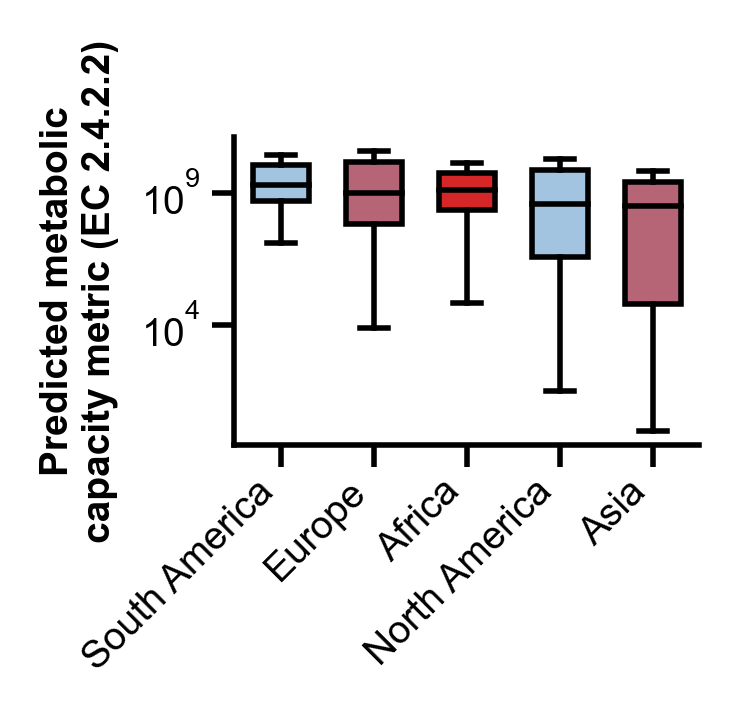

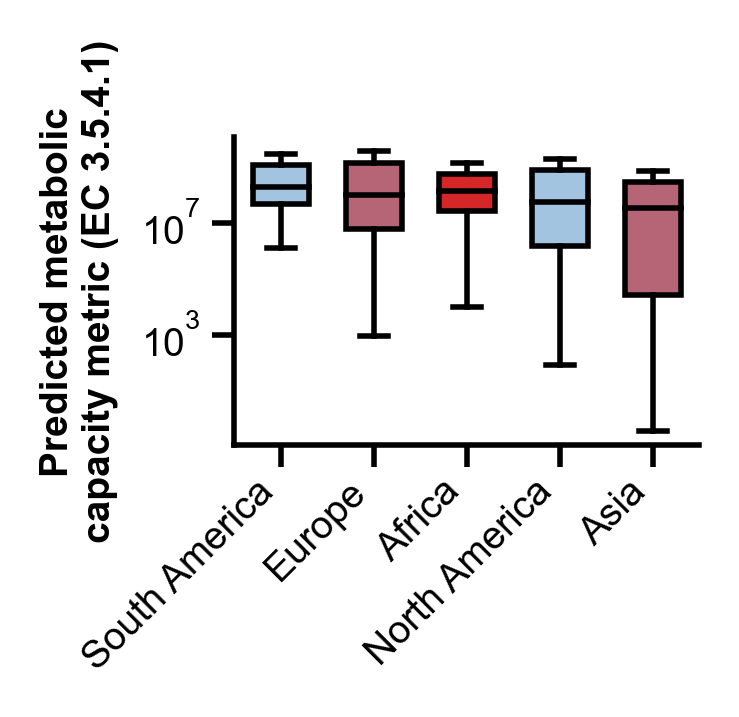

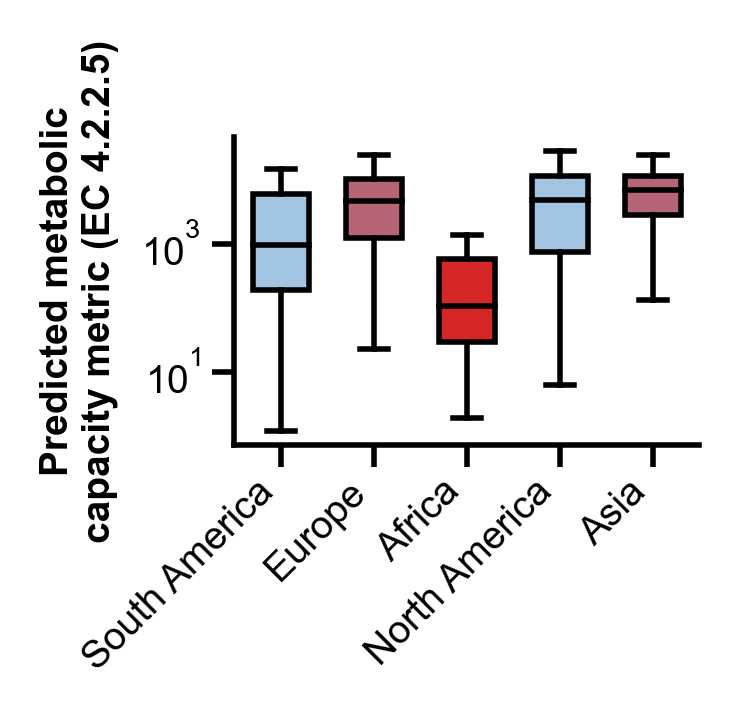

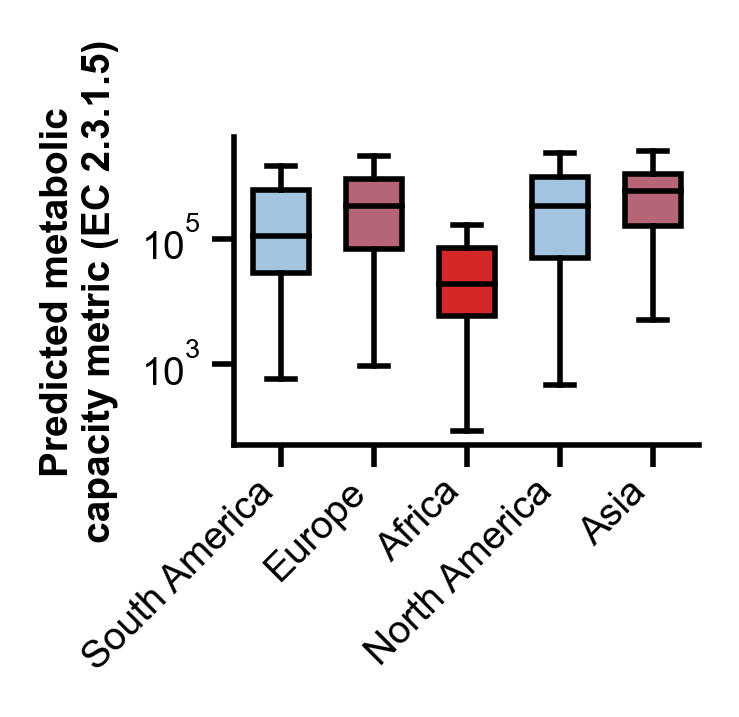

In [38]:
letters = ['b', 'c', 'd', 'e']

for i, EC in enumerate(list(score_import_EC.keys())):

    letter = letters[i]

    score_1 = score_import_EC[EC]

    medians = {label: np.median(scores) for label, scores in score_1.items()}

    people_ids = ['South America','Europe', 'Africa','North America', 'Asia']

    def remove_outliers_log(data):
        log_data = np.log10(data)
        q1 = np.percentile(log_data, 25)
        q3 = np.percentile(log_data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return [x for x in data if lower <= np.log10(x) <= upper]

    all_data = [remove_outliers_log(score_1[label]) for label in people_ids]

    plt.figure(figsize=(1.5, 1), dpi=400)
    plt.rcParams.update({'font.size': 7})
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['pdf.fonttype'] = 42

    plt.gca().spines['top'].set_linewidth(0)
    plt.gca().spines['bottom'].set_linewidth(1)
    plt.gca().spines['left'].set_linewidth(1)
    plt.gca().spines['right'].set_linewidth(0)

    colors = ['#A2C4E0', '#B56576', '#D62728']
    group_colors = ['#A2C4E0', '#B56576', '#D62728']

    positions = np.arange(len(people_ids)) + 0.5

    box = plt.boxplot(all_data, positions=positions, widths=0.6,
                      patch_artist=True, showfliers=False)

    for i2, patch in enumerate(box['boxes']):
        patch.set_facecolor(colors[i2 % len(colors)])
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    for part in ['whiskers', 'caps', 'medians']:
        for line in box[part]:
            line.set_color('black')
            line.set_linewidth(1)

    plt.xticks(positions, people_ids, fontsize=7, rotation=45, ha='right')

    plt.ylabel(f"Predicted metabolic\ncapacity metric (EC {EC})", 
               fontsize=7, fontweight='bold')  # 设置 y 轴标签，字体加粗

    plt.yscale('log')
    plt.tick_params(axis='y', direction='out', width=1, length=4, pad=2)
    plt.tick_params(axis='x', direction='out', width=1, length=4, pad=1)
    plt.minorticks_off()

    # ✅ 每个图单独保存
    plt.savefig(f'../../Figure/Figure-4{letter}.pdf',
                dpi=400, bbox_inches='tight')

    plt.show()